In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
data = pd.read_csv("../data/study_hours_scores_regression.csv")
data

,Hours,Scores
0,8.87,36.80
1,4.45,51.88
2,7.08,85.64
3,2.17,51.23
4,5.23,96.27
...,...,...
95,3.39,0.46
96,4.62,99.42
97,2.12,42.63
98,0.33,30.99


In [3]:
X = (data.Hours).to_numpy()
y = (data.Scores).to_numpy()

In [4]:
X

array([8.87, 4.45, 7.08, 2.17, 5.23, 4.28, 8.58, 0.02, 6.08, 2.51, 4.64,
       2.49, 5.78, 2.36, 1.22, 1.81, 8.84, 9.69, 4.77, 9.91, 5.66, 6.61,
       9.16, 5.05, 3.87, 3.28, 8.73, 2.96, 3.67, 1.01, 0.03, 0.42, 2.49,
       1.34, 0.85, 5.23, 1.96, 0.33, 7.61, 2.59, 4.19, 9.02, 2.22, 0.48,
       6.67, 2.11, 2.84, 5.07, 0.99, 2.18, 8.19, 2.73, 9.08, 2.62, 3.25,
       9.08, 1.41, 7.17, 9.23, 5.66, 3.09, 6.04, 2.36, 6.17, 9.42, 8.52,
       4.47, 0.72, 1.34, 3.28, 8.76, 7.  , 8.15, 5.94, 3.54, 3.6 , 9.25,
       1.88, 7.73, 4.68, 1.35, 6.78, 3.5 , 6.43, 1.97, 6.93, 3.9 , 5.15,
       7.39, 7.07, 7.84, 1.39, 1.55, 5.02, 4.5 , 3.39, 4.62, 2.12, 0.33,
       5.89])

In [5]:
y

array([36.8 , 51.88, 85.64, 51.23, 96.27, 24.3 , 51.92,  1.33, 73.71,
       81.33, 13.38, 67.27,  3.1 , 72.47, 59.78, 32.81,  7.6 , 31.61,
       13.27, 78.2 , 19.65, 77.01, 92.22, 25.42, 54.77, 16.62, 90.51,
       23.44, 74.82, 89.89, 92.49, 65.56, 96.86, 57.17, 92.45, 10.58,
       62.79, 28.79, 66.62,  1.05, 49.73, 57.62, 74.22, 87.21, 60.92,
       20.72, 54.99, 41.82, 38.16, 15.33, 22.58, 34.31, 22.56, 82.31,
        7.18, 20.46, 86.01,  4.81, 86.43,  8.13, 54.65, 78.59, 47.82,
       60.43, 55.29, 19.03, 94.61, 88.31, 75.56, 86.03, 87.01, 25.57,
       37.67, 39.74, 11.75, 90.49, 61.97,  6.1 , 40.71, 79.42, 31.53,
        5.62, 69.57, 93.55, 62.8 , 64.26, 56.7 ,  5.27, 61.74, 59.24,
       46.11, 53.79, 29.08, 56.11, 55.35,  0.46, 99.42, 42.63, 30.99,
       65.19])

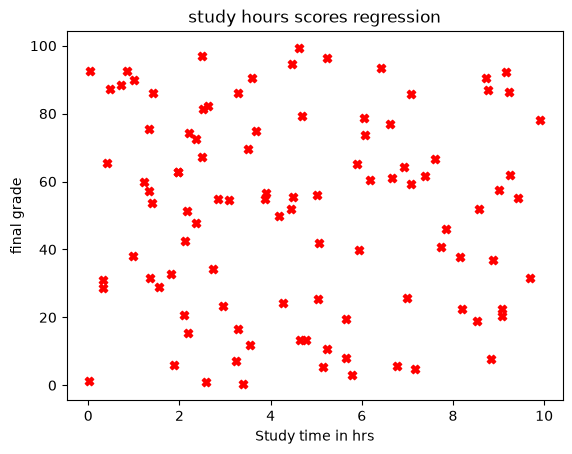

In [6]:
plt.scatter(X, y ,marker="X", c="r")
plt.xlabel("Study time in hrs")
plt.ylabel("final grade")
plt.title("study hours scores regression")
plt.show()

In [7]:
def compute_fwb(x, w, b):
    m = x.shape[0]
    f_wd = np.zeros(m)
    for i in range(m):
        f_wd[i] = w*x[i] + b
    return f_wd

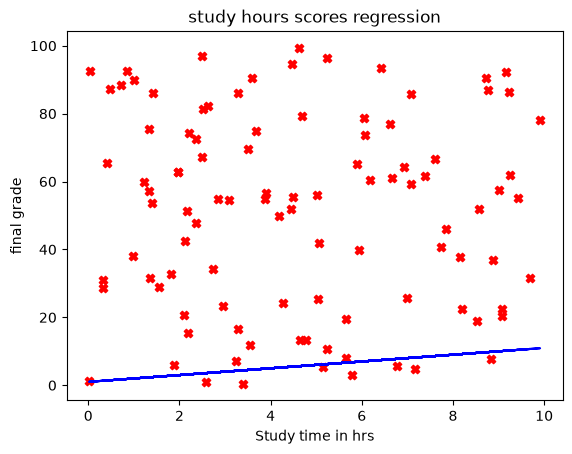

In [8]:
temp_fwb = compute_fwb(X, 1, 1)

plt.plot(X, temp_fwb, c="b", label="Our Prediction")
plt.scatter(X, y ,marker="X", c="r", label="Factual Values")
plt.xlabel("Study time in hrs")
plt.ylabel("final grade")
plt.title("study hours scores regression")
plt.show()

In [9]:
def cost_compute(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        fwb = w*x[i]+b
        cost += (fwb - y[i])**2
    
    return cost/(2*m)

In [10]:
def compute_gradient(x, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = x.shape[0]

    for i in range(m):
        fwb = w*x[i] + b

        dj_dw += (fwb-y[i])*x[i]
        dj_db += (fwb-y[i])

    return dj_dw/m, dj_db/m

In [11]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, gradient_function, cost_function, tolerance = 1e-6):
    j_history = []
    p_history = []

    c1 = 0
    c2 = 0

    w = w_in
    b = b_in
    for i in range(num_iter):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost = cost_function(x, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])

        c2 = c1
        c1 = cost

        if i % math.ceil(num_iter/10) == 0:
            print(f"Iteration: {i:4} Cost: {j_history[-1]:0.2e}",
                  f"dj_dw: {dj_dw:0.3e} dj_db: {dj_db:0.3e}",
                  f"w: {w:0.3e} b: {b:0.3e}")
        if abs(c1 - c2) < tolerance:
            break

    return w, b, j_history, p_history
        

In [12]:
w = 0
b = 0
alpha = 1e-2
num_iter = 10000

w_final, b_final, j_hist, p_hist = gradient_descent(X, y, w, b, alpha, num_iter, compute_gradient, cost_compute)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})\n")

Iteration:    0 Cost: 1.23e+03 dj_dw: -2.306e+02 dj_db: -5.078e+01 w: 2.306e+00 b: 5.078e-01
Iteration: 1000 Cost: 4.17e+02 dj_dw: 1.563e-01 dj_db: -9.769e-01 w: 1.585e-01 b: 4.908e+01
Iteration: 2000 Cost: 4.15e+02 dj_dw: 1.129e-02 dj_db: -7.055e-02 w: -3.926e-01 b: 5.252e+01
(w,b) found by gradient descent: ( -0.4295, 52.7525)



In [13]:
print(X[:10])
print(y[:10])

print("X mean:", X.mean())
print("y mean:", y.mean())

print("Correlation:", np.corrcoef(X, y)[0, 1])

[8.87 4.45 7.08 2.17 5.23 4.28 8.58 0.02 6.08 2.51]
[36.8  51.88 85.64 51.23 96.27 24.3  51.92  1.33 73.71 81.33]
X mean: 4.6088
y mean: 50.7827
Correlation: -0.04224338564185159


In [14]:
# Study Hours vs Score
# Linear regression is not useful for this dataset because
# the correlation is near zero and there is no clear linear relationship.
#
# Therefore, we are shifting to a dataset with a clear linear relationship:
# Years of Experience vs Salary.